1. Standard Scaling
Standard scaling is a method of scaling the data such that the distribution of the data is centered around 0, with a standard deviation of 1. This is done by subtracting the mean of the data from each data point and then dividing by the standard deviation of the data. This is a very common method of scaling data, and is used in many machine learning algorithms.

The formula is as follows:

z = (x - μ) / σ

In [1]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler


In [2]:
# make an example dataset
df = {
    'age': [25,30,35,40,45],
    'height': [165,170,175,180,185],
    'weight': [55,60,65,70,75]
}

# conver this data to pandas datafram
df = pd.DataFrame(df)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


In [7]:
# import the scalar
scalar = StandardScaler()

# fit the scalar on data
scaled_df = scalar.fit_transform(df)
scaled_df
# convert this data into a pandas dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


Explaining StandardScaler MinMaxScaler MaxAbsScaler in Roman Urdu with Examples
Aapke sawaal ka jawaab Roman Urdu mein:
Scaling kya hai?
Machine learning mein data ko normalize ya standardize karna zaroori hota hai taake alag-alag features ki values ek hi range mein aa jaayein. Is se model behtar kaam karta hai.
1. StandardScaler
Iska matlab hai data ko aisa transform karna ke uska mean 0 aur standard deviation 1 ho jaaye.
Formula: z = (x - mean) / std

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler

data = np.array([[10], [20], [30], [40], [50]])
scaler = StandardScaler()
scaled = scaler.fit_transform(data)

# Result approximate hoga:
[[-1.41], [-0.71], [0.0], [0.71], [1.41]]

[[-1.41], [-0.71], [0.0], [0.71], [1.41]]

2. MinMaxScaler
Iska kaam hai data ko fixed range mein laana, aksar 0 aur 1 ke beech mein.
Formula: x_scaled = (x - min) / (max - min)
Example:

In [5]:
from sklearn.preprocessing import MinMaxScaler

data = np.array([[10], [20], [30], [40], [50]])
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
[[0.0], [0.25], [0.5], [0.75], [1.0]]
# Interpretation: Sabse choti value (10) 0 ban gayi aur sabse bari value (50) 1 ban gayi. Baqi values proportionally 0 aur 1 ke beech mein hain.

[[0.0], [0.25], [0.5], [0.75], [1.0]]

3. MaxAbsScaler
Ye data ko -1 se 1 ke beech mein scale karta hai, har feature ke maximum absolute value se divide karke.
Formula: x_scaled = x / max(|x|)
Example:

In [6]:
from sklearn.preprocessing import MaxAbsScaler

data = np.array([[10], [20], [-30], [40], [50]])
scaler = MaxAbsScaler()
scaled = scaler.fit_transform(data)

# Result hoga:
[[0.2], [0.4], [-0.6], [0.8], [1.0]]

[[0.2], [0.4], [-0.6], [0.8], [1.0]]

Kab Konsa Istemal Karein?
StandardScaler: Jab data normal distribution follow kare ya outliers na hon
MinMaxScaler: Jab specific range chahiye ho (0-1) aur outliers na hon
MaxAbsScaler: Jab data mein negative values hon aur sparsity bachani ho

In [8]:

from sklearn.preprocessing import RobustScaler

# import the scalar
scalar = RobustScaler()

# fit the scalar on data
scaled_df = scalar.fit_transform(df)
scaled_df
# convert this data into a pandas dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0



Transformation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# generate non-normal data (exponential Distribution)
np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['values'])
df.head()

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='values', ylabel='Count'>

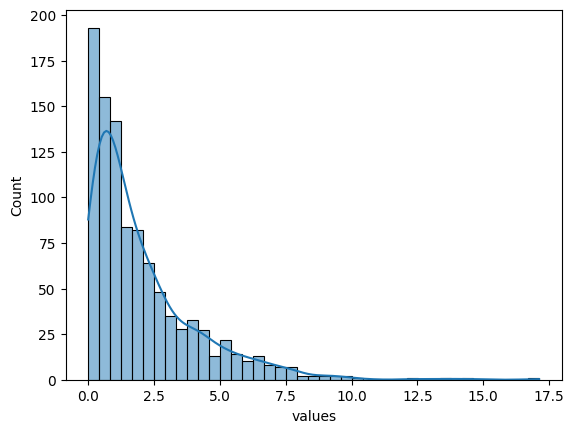

In [4]:
sns.histplot(df['values'], kde=True)

In [5]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

# boxbcox k liay data must be postive
df['Box_Cox'] = pt_boxcox.fit_transform(df[['values']] + 1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['Quantile'] = qt_normal.fit_transform(df[['values']])
df.head()

,values,Box_Cox,Yeo_Johnson,Quantile
0,1.591749,0.787485,0.787485,0.162552
1,2.511862,0.980233,0.980233,0.587964
2,1.846446,0.849553,0.849553,0.286135
3,1.574402,0.782945,0.782945,0.157469
4,1.102097,0.639848,0.639848,-0.154930


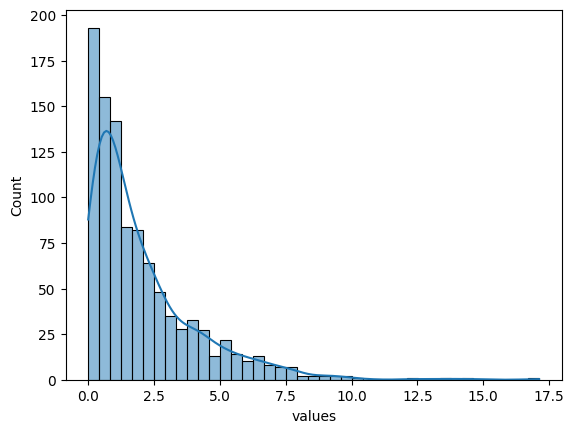

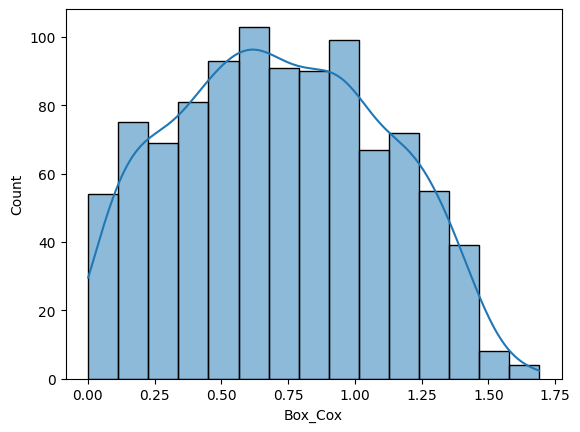

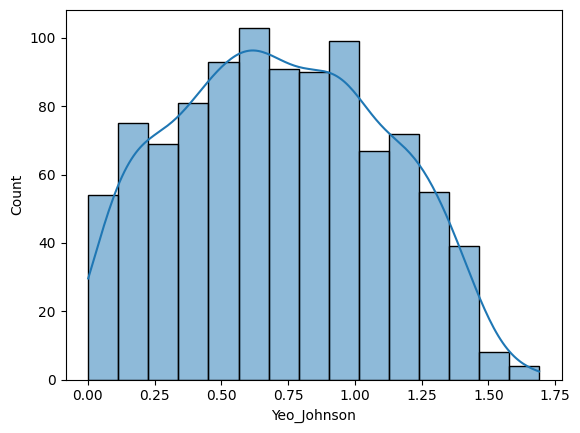

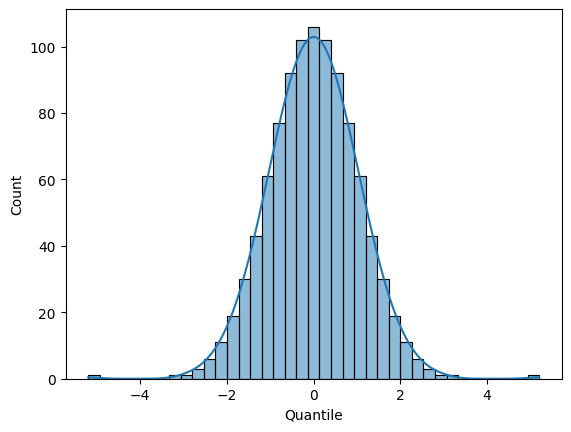

In [6]:
# creata hostograms for all columns using sns.hist and kde=true use a for loop
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()

L2 Normalization:
Rescales each sample (row) to have unit norm. This type of normalization is often used when dealing with text data. The L2 norm is calculated as the square root of the sum of the squared vector values.

In [7]:
from sklearn.preprocessing import Normalizer
data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]
normalizer = Normalizer(norm='l2')
print(normalizer.fit_transform(data))


[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]



L1 Normalization:
Also rescales each sample (row) but with a different approach, ensuring the sum of the absolute values is 1 in each row. The L1 norm is calculated as the sum of the absolute vector values. Example:

In [8]:
from sklearn.preprocessing import Normalizer
data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]
normalizer = Normalizer(norm='l1')
print(normalizer.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


Log Transformation

In [9]:
import pandas as pd
import numpy as np

# example dataset with skewed values
df = { "Values": [1,5,10,20,50,100,200,500,1000,2000,5000,10000,20000,50000,100000]}
df = pd.DataFrame(df)
df.head()

,Values
0,1
1,5
2,10
3,20
4,50


In [10]:
df['log_values'] = np.log(df['Values'])
df


,Values,log_values
0,1,0.000000
1,5,1.609438
2,10,2.302585
3,20,2.995732
4,50,3.912023
5,100,4.605170
6,200,5.298317
7,500,6.214608
8,1000,6.907755
9,2000,7.600902


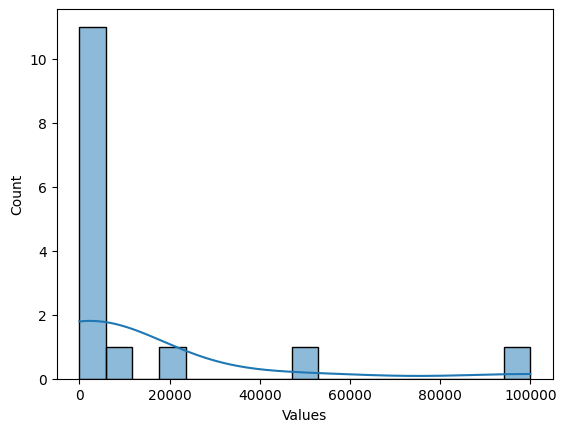

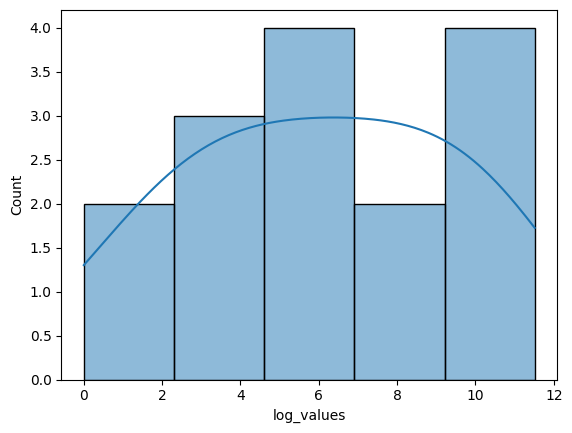

In [11]:
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()